In [1]:
import numpy as np
data = np.load("/home/notebook/data/personal/S9063410/bp_data_one_channel/OPPO_Watch4_Pro/1000135070/1000135070-20251004150950.npz")
print(list(data.keys()))
ppg = data['g0_c0']
print("PPG Shape:", ppg.shape)
print("Duration:", data["duration"])


['duration', 'g0_c0', 'ir_c0', 'gyro']
PPG Shape: (6000,)
Duration: 60.0


keys: ['duration', 'GR', 'IR', 'gyro']


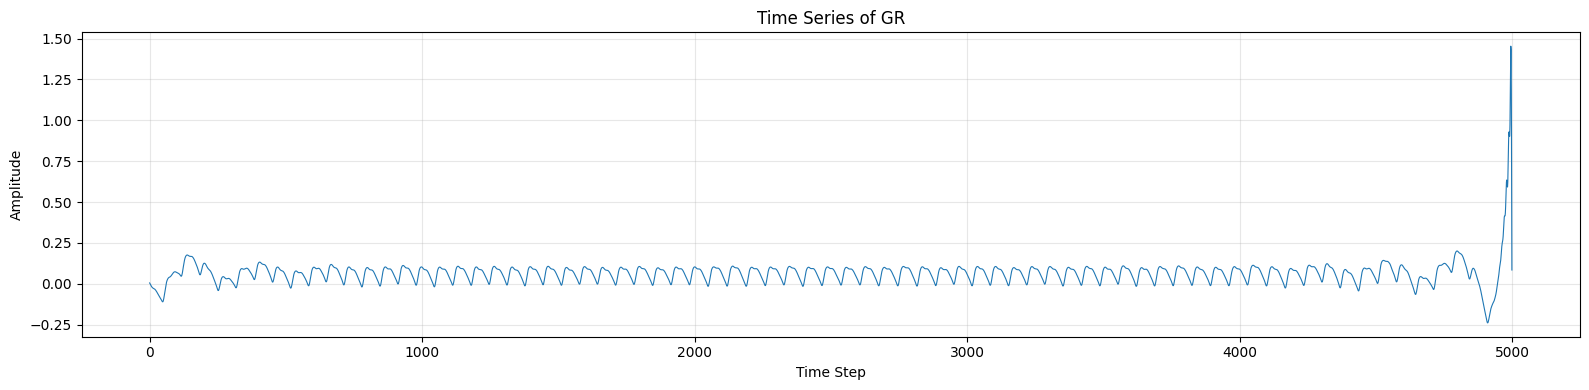

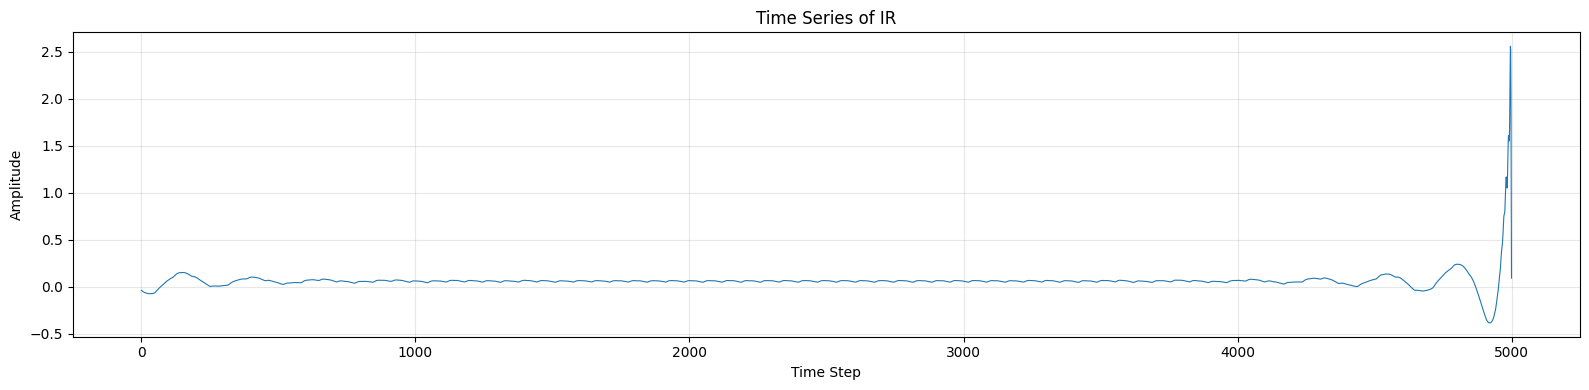

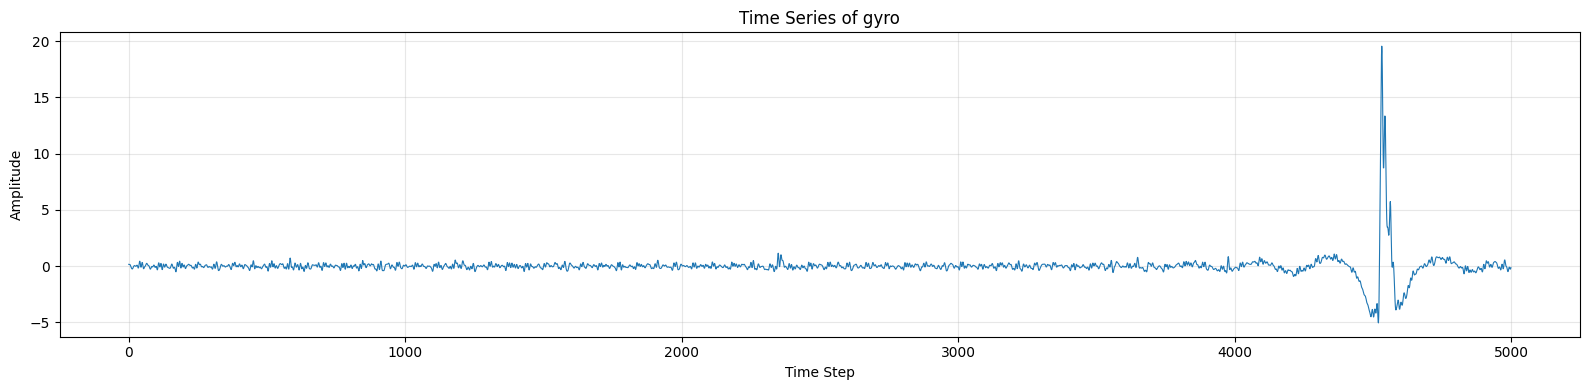

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ====== 1. 读取 npz ======
npz_path = "/home/notebook/data/personal/S9063410/bp_data_one_channel/OPPO_Watch4_Pro/1000135070/1000135070-20251004150950.npz"
data = np.load(npz_path, allow_pickle=True)

print("keys:", data.files)

# ====== 2. 需要画图的信号 ======
signal_keys = [k for k in data.files if k != "duration"]

# ====== 3. 逐个画时序图 ======
for key in signal_keys:
    signal = data[key][1000:]

    # 有些数组可能 shape 是 (N, 1) 或 (1, N)，压成 1 维
    signal = np.squeeze(signal)

    # 跳过非一维数据
    if signal.ndim != 1:
        print(f"skip {key}: shape = {signal.shape}, not 1D")
        continue

    plt.figure(figsize=(16, 4))
    plt.plot(signal, linewidth=0.8)
    plt.title(f"Time Series of {key}")
    plt.xlabel("Time Step")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()